[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Arabas_and_Pawlowska_2011/fig_2.ipynb)

#### based on Fig. 2 from Arabas and Pawlowska 2011 "Adaptive method of lines for multi-component aerosol condensational growth and CCN activation"
https://doi.org/10.5194/gmd-4-15-2011

In [1]:
import os, sys

os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples>=3.0.0rc30', 'PySDM>=3.0.0rc30')

In [2]:
import numpy as np
from matplotlib import pyplot, cm, colors
from PySDM.physics import si, in_unit
from PySDM.physics.constants import PER_CENT
from PySDM_examples.Arabas_and_Pawlowska_2011 import Simulation, Settings

settings = Settings()
simulation = Simulation(settings)

output = simulation.run()

particulator = simulation.particulator
mode_id = simulation.mode_id

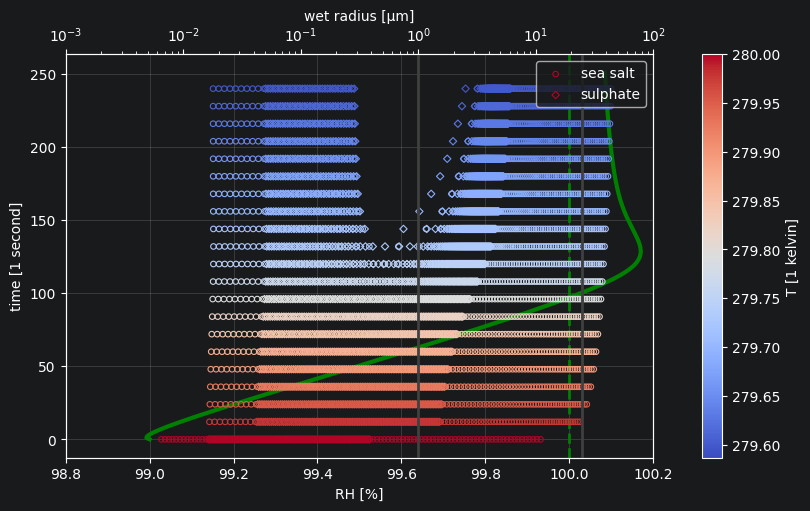

In [3]:
fig, ax = pyplot.subplots(figsize=(8, 5), constrained_layout=True)

ax.set_xlabel("RH [%]")
ax.set_ylabel(f"time [{particulator.products['time'].unit}]")

ax.plot(
    in_unit(output["RH"], PER_CENT),
    output["time"],
    color="green",
    linewidth=3,
)

ax.axvline(
    x=100,
    color="green",
    linestyle="--",
    linewidth=2,
)

ax.set_xlim(98.8, 100.2)
ax.grid(True, which="both", alpha=0.3)
ax_top = ax.twiny()
ax_top.set_xlabel("wet radius [μm]")
ax_top.set_xscale("log")
ax_top.set_xlim(1e-3, 1e2)

T_values = np.asarray(output["T"])

norm = colors.Normalize(
    vmin=T_values.min(),
    vmax=T_values.max(),
)

cmap = pyplot.get_cmap("coolwarm")

sea_salt_indices = np.where(mode_id == 0)[0][::5]
sulphate_indices = np.where(mode_id == 1)[0][::5]

plot_every = 12

for radius, time, T in zip(
    output["radius"][::plot_every],
    output["time"][::plot_every],
    output["T"][::plot_every],
):
    radius_um = radius / si.um
    color = cmap(norm(T))

    ax_top.scatter(
        radius_um[sea_salt_indices],
        np.full(len(sea_salt_indices), time),
        marker="o",
        facecolors="none",
        edgecolors=color,
        s=16,
        linewidths=0.8,
        label="sea salt" if time == output["time"][0] else None,
    )

    ax_top.scatter(
        radius_um[sulphate_indices],
        np.full(len(sulphate_indices), time),
        marker="D",
        facecolors="none",
        edgecolors=color,
        s=14,
        linewidths=0.8,
        label="sulphate" if time == output["time"][0] else None,
    )

ax_top.axvline(
    settings.cloud_range[0] / si.um,
    color="0.25",
    linewidth=2,
)

ax_top.axvline(
    settings.cloud_range[1] / si.um,
    color="0.25",
    linewidth=2,
)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=(ax, ax_top))
cbar.set_label(f"T [{particulator.products['T'].unit}]")

ax_top.legend(loc="upper right")